# ECC Tensile Prediction: CatBoost + Mondrian CQR

End-to-end pipeline for predicting **Second Stress** (tensile strength, MPa) and **Second Strain** (ductility, %) of Engineered Cementitious Composites from mix-design parameters.

**Pipeline:**
1. Preprocessing & group-level aggregation (37 features)
2. CatBoost quantile regressors (q10 / q50 / q90) — forward model
3. Mondrian CQR — calibrated 80% prediction intervals
4. Inverse design — three cost tiers (Budget / Standard / Premium)

Outputs are saved to `results/`.

In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [2]:
import catboost

In [3]:
import re
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

EPS = 1e-8
RANDOM_STATE = 42
EXCEL_PATH = "Tension Test_VIT_re.xlsx"
SHEET_NAME = "Tension Test_VIT"
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


In [4]:
# --- Preprocessing (reimplemented from ECC backend workflow) ---
raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
raw = raw.rename(columns={"Water Reducer / SP": "Water Reducer/SP"})
df = raw.copy()


def extract_age(row):
    for col in ["Specimen", "Mixture"]:
        v = str(row.get(col, ""))
        m = re.search(r"(\d+)\s*[dD]", v)
        if m:
            return int(m.group(1))
    return None


ages = df.apply(extract_age, axis=1)
mask_drop = ages.notna() & (ages < 28)
df = df[~mask_drop].reset_index(drop=True)

GROUP_COLS = [
    "Fiber Volume", "L/D", "RI", "Cement", "Water", "Sand",
    "Fly ash C", "Fly ash F", "GGBS", "Coarse Aggr.",
    "Silica Fume", "Water Reducer/SP", "W/B"
]
for c in GROUP_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

df["_fp"] = df[GROUP_COLS].round(4).apply(lambda r: "|".join(map(str, r.values)), axis=1)
df["group_id"] = pd.factorize(df["_fp"])[0]

df["Binder"] = df["Cement"] + df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]
df["Paste"] = df["Binder"] + df["Water"]
df["Total_Aggregates"] = df["Sand"] + df["Coarse Aggr."]

# Group A
df["FA/Binder Ratio"] = (df["Fly ash F"] + df["Fly ash C"]) / (df["Binder"] + EPS)
df["S/B Ratio"] = df["Sand"] / (df["Binder"] + EPS)

# Group B
df["Paste Volume"] = df["Paste"]
df["SCM Ratio"] = (df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]) / (df["Cement"] + EPS)
df["Aggregate Ratio"] = df["Total_Aggregates"] / (df["Paste"] + EPS)
df["Fiber Surface Area"] = df["Fiber Volume"] * (df["Length (mm)"] / (df["Diameter (mm)"] + EPS))
df["Fiber Efficiency"] = df["Fiber Volume"] * df["L/D"]
df["GGBS Presence"] = (df["GGBS"] > 0).astype(int)
df["Silica Fume Presence"] = (df["Silica Fume"] > 0).astype(int)
df["Coarse Agg Presence"] = (df["Coarse Aggr."] > 0).astype(int)

# Group C
df["tau_proxy"] = 1.0 / (df["W/B"] + EPS)
df["Flaw Size Proxy"] = df["Aggregate Ratio"] + df["W/B"]
df["Geometric Fiber Eff"] = df["Fiber Volume"] * (df["L/D"] ** 2)
df["sigma_cu_proxy"] = df["tau_proxy"] * df["Fiber Volume"] * df["L/D"]
df["sigma_crack_proxy"] = 1.0 / (df["Flaw Size Proxy"] + EPS)
df["PSH Strength Index"] = df["sigma_cu_proxy"] / (df["sigma_crack_proxy"] + EPS)
df["Jb_complement"] = df["tau_proxy"] * df["Fiber Volume"] * (df["L/D"] ** 2)
df["J_tip_proxy"] = 1.0 / (df["Flaw Size Proxy"] + EPS)
df["PSH Energy Index"] = df["Jb_complement"] / (df["J_tip_proxy"] + EPS)

ENG_COLS = [
    "FA/Binder Ratio", "S/B Ratio", "Paste Volume", "SCM Ratio", "Aggregate Ratio",
    "Fiber Surface Area", "Fiber Efficiency", "GGBS Presence", "Silica Fume Presence",
    "Coarse Agg Presence", "tau_proxy", "Flaw Size Proxy", "Geometric Fiber Eff",
    "sigma_cu_proxy", "sigma_crack_proxy", "PSH Strength Index", "Jb_complement",
    "J_tip_proxy", "PSH Energy Index"
]
for c in ENG_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].fillna(df[c].median())

RAW_NUMERIC = [
    "Fiber Volume", "Length (mm)", "Diameter (mm)", "L/D", "RI",
    "Cement", "Water", "Sand", "Fly ash C", "Fly ash F", "GGBS",
    "Coarse Aggr.", "Silica Fume", "Water Reducer/SP", "Fiber",
    "C/B", "W/C", "W/B"
]
for c in RAW_NUMERIC:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

if "Shape Factor" in df.columns:
    df = df.drop(columns=["Shape Factor"])

ALL_37_FEATURES = RAW_NUMERIC + ENG_COLS
TARGETS = ["Second Stress", "Second Strain"]
for t in TARGETS:
    df[t] = pd.to_numeric(df[t], errors="coerce")

df = df.dropna(subset=TARGETS).reset_index(drop=True)

print(f"Processed rows: {len(df)}")
print(f"Unique composition groups: {df['group_id'].nunique()}")
print(f"Feature count: {len(ALL_37_FEATURES)}")

Processed rows: 620
Unique composition groups: 276
Feature count: 37


In [5]:
X = df[ALL_37_FEATURES].values
groups = df["group_id"].values

CB_PARAMS_STRAIN = {
    "iterations": 600,
    "depth": 9,
    "learning_rate": 0.12604670759479358,
    "l2_leaf_reg": 0.2919794366938302,
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}

CB_PARAMS_STRESS = {
    "iterations": 800,
    "depth": 10,
    "learning_rate": 0.03156119992394155,
    "l2_leaf_reg": 0.20410490729823838,
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}

REGIME_CUTOFFS = {
    "Second Strain": (0.005, 0.050, 0.0015),
    "Second Stress": (4.0, 5.13, 0.20),
}
REGIME_NAMES = {
    "Second Strain": ("NoPSH", "Bulk", "Tail"),
    "Second Stress": ("Weak", "Mid", "Strong"),
}


def make_catboost_quantile(alpha, target):
    params = CB_PARAMS_STRESS if target == "Second Stress" else CB_PARAMS_STRAIN
    return CatBoostRegressor(loss_function=f"Quantile:alpha={alpha}", **params)


def build_group_means(df_in, target):
    g = df_in.groupby("group_id").agg(
        **{col: (col, "mean") for col in ALL_37_FEATURES + [target]},
        n_rep=("group_id", "count"),
        tgt_var=(target, "var"),
    ).reset_index()
    g["tgt_var"] = g["tgt_var"].fillna(0.0)
    g["sample_weight"] = g["n_rep"] / (g["tgt_var"] + 0.1)

    c1, c2, _ = REGIME_CUTOFFS[target]
    low, mid, high = REGIME_NAMES[target]
    y = g[target].values
    g["regime"] = np.where(y < c1, low, np.where(y < c2, mid, high))
    return g


def mondrian_qhat(cal_scores, cal_q50_pred, val_q50_pred, alpha=0.20):
    q33 = np.quantile(cal_q50_pred, 1/3)
    q67 = np.quantile(cal_q50_pred, 2/3)
    cb = np.where(cal_q50_pred <= q33, 0, np.where(cal_q50_pred <= q67, 1, 2))
    vb = np.where(val_q50_pred <= q33, 0, np.where(val_q50_pred <= q67, 1, 2))

    out = np.zeros(len(val_q50_pred))
    for b in range(3):
        mc = cb == b
        mv = vb == b
        n_b = mc.sum()
        if n_b == 0:
            out[mv] = np.quantile(cal_scores, 1 - alpha) if len(cal_scores) else 0
        else:
            lvl = min(np.ceil((n_b + 1) * (1 - alpha)) / n_b, 1.0)
            out[mv] = np.quantile(cal_scores[mc], lvl)
    return out


def fit_predict_catboost(X_train, y_train, w_train, X_pred, target):
    m50 = make_catboost_quantile(0.50, target)
    m50.fit(X_train, y_train, sample_weight=w_train)
    q50 = m50.predict(X_pred)

    m10 = make_catboost_quantile(0.10, target)
    m10.fit(X_train, y_train, sample_weight=w_train)
    q10 = m10.predict(X_pred)

    m90 = make_catboost_quantile(0.90, target)
    m90.fit(X_train, y_train, sample_weight=w_train)
    q90 = m90.predict(X_pred)

    return q10, q50, q90


def run_catboost_mondrian_cv(g, target, alpha=0.20):
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    y_all = g[target].values
    groups_arr = g["group_id"].values
    gkf = GroupKFold(n_splits=5)

    N = len(g)
    p50 = np.full(N, np.nan)
    lo = np.full(N, np.nan)
    hi = np.full(N, np.nan)

    for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(g, y_all, groups_arr), start=1):
        g_tr = g.iloc[tr_idx].reset_index(drop=True)
        g_va = g.iloc[val_idx].reset_index(drop=True)

        y_tr = g_tr[target].values
        w_tr = g_tr["sample_weight"].values

        tr_uniq = g_tr["group_id"].unique()
        rng = np.random.default_rng(fold_idx)
        rng.shuffle(tr_uniq)
        n_fit = int(0.75 * len(tr_uniq))
        fit_grp = set(tr_uniq[:n_fit])

        fit_mask = g_tr["group_id"].isin(fit_grp).values
        cal_mask = ~fit_mask

        X_tr = g_tr[ALL_37_FEATURES].values
        X_fit = g_tr.loc[fit_mask, ALL_37_FEATURES].values
        X_cal = g_tr.loc[cal_mask, ALL_37_FEATURES].values
        X_va = g_va[ALL_37_FEATURES].values

        y_fit = y_tr[fit_mask]
        y_cal = y_tr[cal_mask]
        w_fit = w_tr[fit_mask]

        q10_va, q50_va, q90_va = fit_predict_catboost(X_tr, y_tr, w_tr, X_va, target)
        q10_cal, q50_cal, q90_cal = fit_predict_catboost(X_fit, y_fit, w_fit, X_cal, target)
        _, q50_va_fit, _ = fit_predict_catboost(X_fit, y_fit, w_fit, X_va, target)

        scores = np.maximum(q10_cal - y_cal, y_cal - q90_cal)
        qhat = mondrian_qhat(scores, q50_cal, q50_va_fit, alpha)

        p50[val_idx] = np.maximum(q50_va, 0)
        lo[val_idx] = np.maximum(q10_va - qhat, 0)
        hi[val_idx] = np.maximum(q90_va + qhat, 0)

    y_true = g[target].values
    metrics = {
        "MAE": mean_absolute_error(y_true, p50),
        "RMSE": np.sqrt(mean_squared_error(y_true, p50)),
        "R2": r2_score(y_true, p50),
        "Cov80": np.mean((y_true >= lo) & (y_true <= hi)),
        "Width80": np.mean(hi - lo),
    }
    return metrics, p50, lo, hi


# Full Mondrian-CQR CatBoost run (both targets)
ALL_RESULTS = {}
for target in ["Second Stress", "Second Strain"]:
    g = build_group_means(df, target)
    metrics, p50, lo, hi = run_catboost_mondrian_cv(g, target, alpha=0.20)
    ALL_RESULTS[target] = {"group_df": g, "metrics": metrics, "p50": p50, "lo": lo, "hi": hi}
    print(f"{target} -> MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}, Cov80={metrics['Cov80']:.3f}, Width80={metrics['Width80']:.4f}")

# ── Full-data models for inverse pipeline ────────────────────────────────────
X_full  = df[ALL_37_FEATURES].values
y_stress = df["Second Stress"].values
y_strain = df["Second Strain"].values
ones_w   = np.ones(len(df))

m_stress_q50 = make_catboost_quantile(0.50, "Second Stress")
m_stress_q50.fit(X_full, y_stress, sample_weight=ones_w)
m_stress_q10 = make_catboost_quantile(0.10, "Second Stress")
m_stress_q10.fit(X_full, y_stress, sample_weight=ones_w)
m_stress_q90 = make_catboost_quantile(0.90, "Second Stress")
m_stress_q90.fit(X_full, y_stress, sample_weight=ones_w)

m_strain_q50 = make_catboost_quantile(0.50, "Second Strain")
m_strain_q50.fit(X_full, y_strain, sample_weight=ones_w)
m_strain_q10 = make_catboost_quantile(0.10, "Second Strain")
m_strain_q10.fit(X_full, y_strain, sample_weight=ones_w)
m_strain_q90 = make_catboost_quantile(0.90, "Second Strain")
m_strain_q90.fit(X_full, y_strain, sample_weight=ones_w)

print("Full-data models trained for inverse pipeline.")


Second Stress -> MAE=0.5090, RMSE=0.7458, R2=0.7355, Cov80=0.851, Width80=2.2069
Second Strain -> MAE=0.0075, RMSE=0.0125, R2=0.5358, Cov80=0.873, Width80=0.0319
Full-data models trained for inverse pipeline.


In [6]:
!pip install pymoo
import pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.5 MB/s eta 0:00:00


Physics-Constrained NSGA-II Inverse Design
PSH Strength threshold : 12.85  (median of real ECC dataset)
PSH Energy threshold   : 3953.0  (median of real ECC dataset)

Running constrained NSGA-II (200 pop × 150 gen)...
Running unconstrained NSGA-II (for comparison)...

Constrained Pareto front : 200 solutions
  Stress : 4.22 – 5.53 MPa
  Strain : 1.25 – 3.78 %
  Cost   : $97.5 – $227.6 /m³

Unconstrained Pareto front: 200 solutions
  Failing calibrated PSH threshold: 52 (26.0%)
  → These mixes are statistically optimal but physically sub-standard.


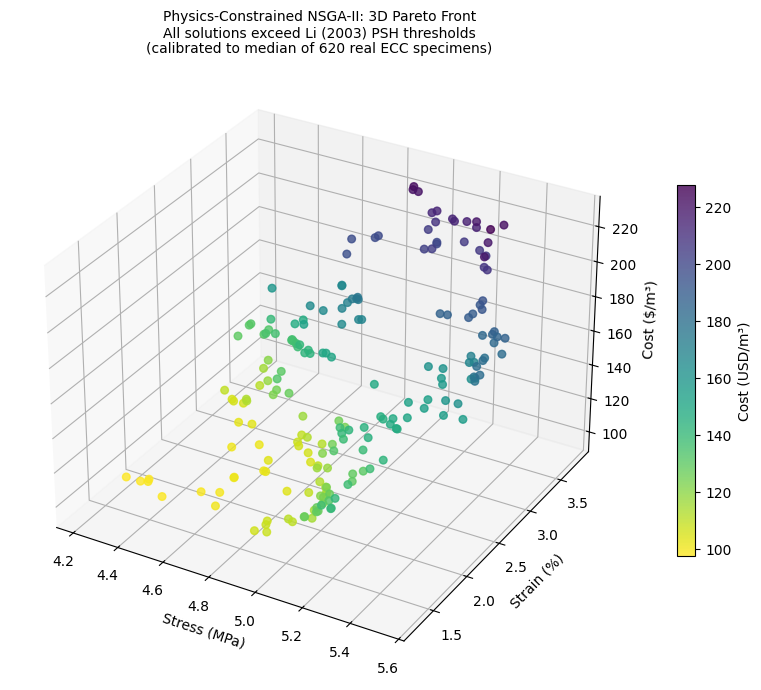

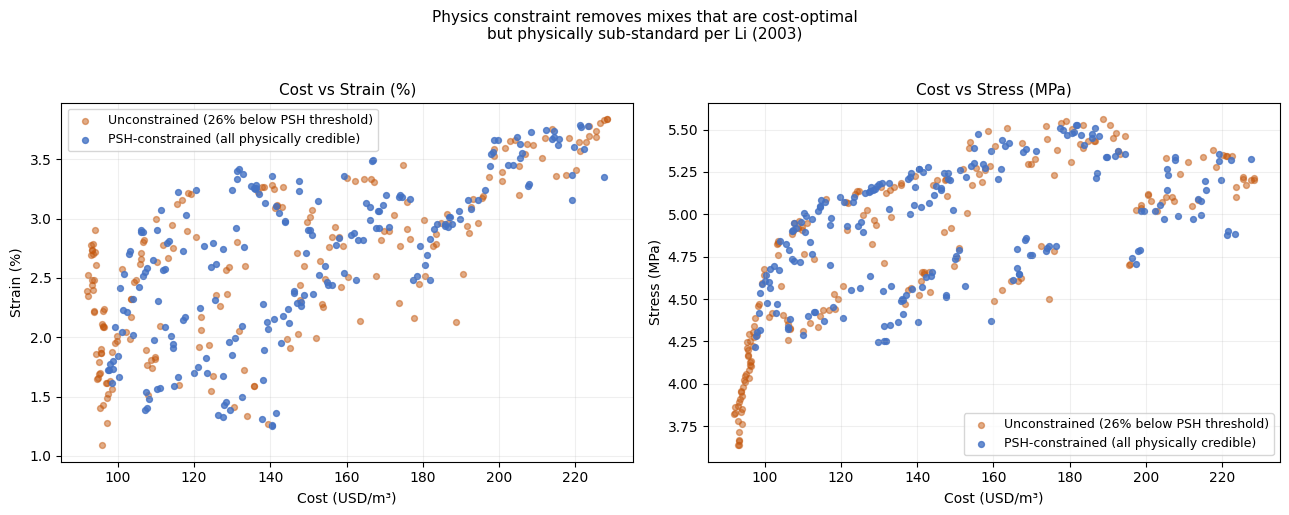

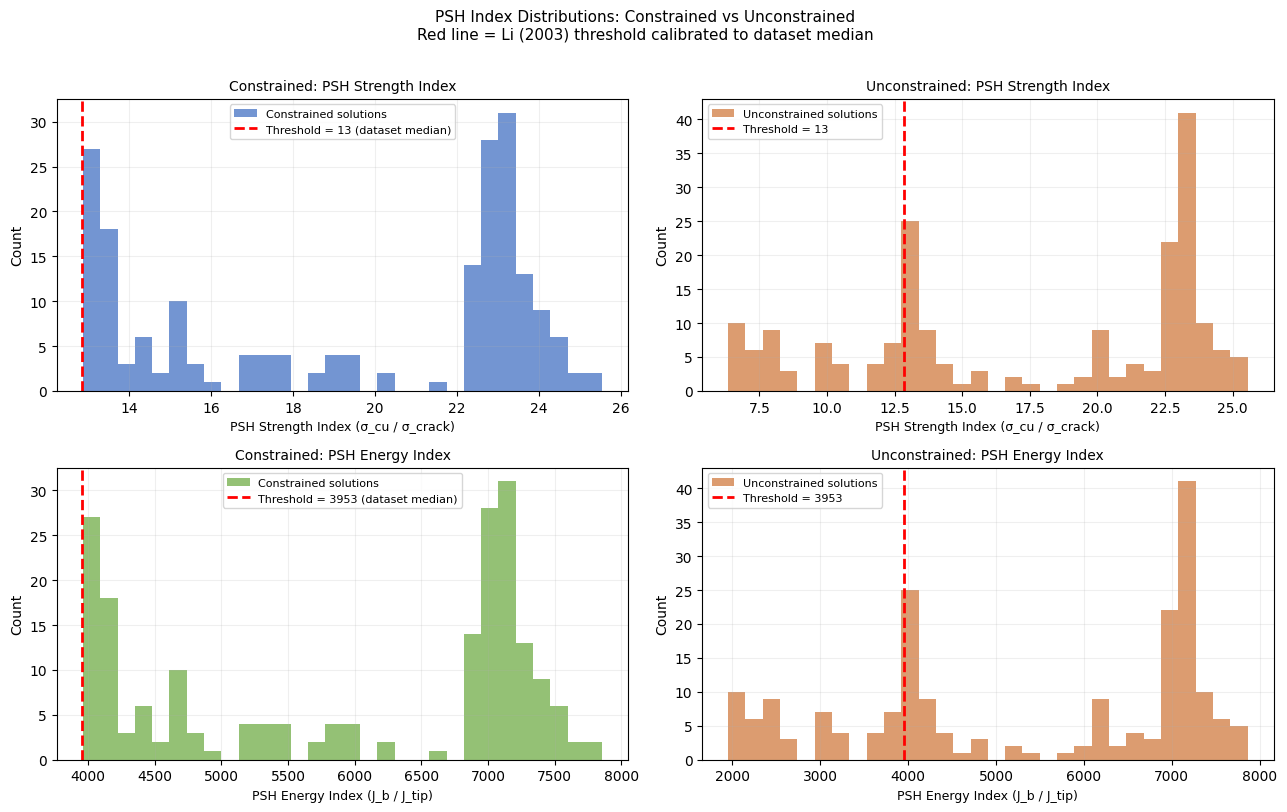


Top 10 Cost-Optimal Mixes (Physics-Constrained Pareto Front)
      Cost ($/m³)  Stress (MPa)  Strain (%)  PSH_Strength  PSH_Energy    Cem    Wat   Sand   FaC    FaF  GGBS    CA   SF   SP
Rank                                                                                                                         
1            97.5          4.22        1.73          12.9      3962.0  300.2  152.2  148.9  21.1  108.8   0.2  76.3  0.2  0.0
2            97.6          4.28        1.73          12.9      3961.0  300.1  152.2  149.1  17.3  115.6   0.4  75.4  0.3  0.1
3            97.9          4.31        1.78          13.0      4008.0  300.2  151.4  150.9  55.5  108.5   0.1  73.2  0.1  0.0
4            98.5          4.42        1.61          13.7      4203.0  300.9  152.2  170.5  22.4  115.8   0.2  79.5  0.4  0.0
5            98.8          4.32        1.73          12.9      3961.0  300.1  152.2  149.1  17.3  115.6   0.4  75.1  2.5  0.1
6            98.9          4.53        1.80          13.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize

EPS = 1e-8

PRICES = {
    'Cement': 0.30420, 'Water': 0.00220, 'Sand': 0.01980,
    'Fly ash C': 0.01349, 'Fly ash F': 0.01349, 'GGBS': 0.07860,
    'Coarse Aggr.': 0.01320, 'Silica Fume': 0.55000,
    'Water Reducer/SP': 1.10000,
}

MIX_INGREDIENT_COLS = [
    'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F',
    'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer/SP'
]

FIBER = dict(Vf=0.02, L=12.0, D=0.039, LD=307.69, RI=6.15, kg=26.0)

LB = np.array([300,   150,    0,    0,    0,    0,    0,     0,    0], dtype=float)
UB = np.array([700,   350,  500,  300,  300,  200,  100,   50,   10], dtype=float)


PSH_S_THRESHOLD = 12.85   # median PSH Strength Index across real specimens
PSH_E_THRESHOLD = 3953.0  # median PSH Energy Index across real specimens


def build_feature_row(mix_arr):
    """
    Reconstruct 37-feature vector from 9-element ingredient array.
    Returns: (X_row (1×37), psh_strength, psh_energy)
    """
    cem, wat, sand, fa_c, fa_f, ggbs, coarse, sf, sp = mix_arr
    Vf, L, D, LD, RI = FIBER['Vf'], FIBER['L'], FIBER['D'], FIBER['LD'], FIBER['RI']

    binder  = cem + fa_f + fa_c + ggbs + sf
    paste   = binder + wat
    total_a = sand + coarse
    wb  = wat  / (binder + EPS)
    wc  = wat  / (cem    + EPS)
    cb  = cem  / (binder + EPS)
    scm = (fa_f + fa_c + ggbs + sf) / (cem + EPS)
    agg_r = total_a / (paste + EPS)
    fa_b  = (fa_f + fa_c) / (binder + EPS)
    s_b   = sand / (binder + EPS)
    fsa   = Vf * L / (D + EPS)
    fe    = Vf * LD
    ggbs_p = float(ggbs   > 0)
    sf_p   = float(sf     > 0)
    ca_p   = float(coarse > 0)
    tau    = 1.0 / (wb + EPS)
    flaw   = agg_r + wb
    geo_fe = Vf * (LD ** 2)
    sig_cu = tau * Vf * LD
    sig_cr = 1.0 / (flaw + EPS)
    psh_s  = sig_cu / (sig_cr + EPS)
    jb_c   = tau * Vf * (LD ** 2)
    j_tip  = 1.0 / (flaw + EPS)
    psh_e  = jb_c / (j_tip + EPS)

    row = [
        Vf, L, D, LD, RI,
        cem, wat, sand, fa_c, fa_f, ggbs, coarse, sf, sp,
        Vf, cb, wc, wb,
        fa_b, s_b,
        paste, scm, agg_r, fsa, fe, ggbs_p, sf_p, ca_p,
        tau, flaw, geo_fe, sig_cu, sig_cr, psh_s, jb_c, j_tip, psh_e,
    ]
    return np.array(row, dtype=float).reshape(1, -1), psh_s, psh_e


def mix_cost(mix_arr):
    return sum(mix_arr[i] * PRICES.get(c, 0)
               for i, c in enumerate(MIX_INGREDIENT_COLS))

class PhysicsConstrainedECC(Problem):
    def __init__(self):
        super().__init__(
            n_var=9, n_obj=3, n_ieq_constr=2,
            xl=LB, xu=UB, elementwise=False
        )

    def _evaluate(self, X, out, *args, **kwargs):
        n = len(X)
        f1 = np.zeros(n)
        f2 = np.zeros(n)
        f3 = np.zeros(n)
        g1 = np.zeros(n)
        g2 = np.zeros(n)

        rows, psh_s_arr, psh_e_arr = [], [], []
        for i in range(n):
            row, psh_s, psh_e = build_feature_row(X[i])
            rows.append(row)
            psh_s_arr.append(psh_s)
            psh_e_arr.append(psh_e)

        X_feat = np.vstack(rows)
        stress_pred = m_stress_q50.predict(X_feat)
        strain_pred = m_strain_q50.predict(X_feat)

        for i in range(n):
            f1[i] = -stress_pred[i]
            f2[i] = -strain_pred[i]
            f3[i] = mix_cost(X[i])
            # Constraint: value ≤ 0 means feasible
            # So: threshold - index ≤ 0  →  index ≥ threshold
            g1[i] = PSH_S_THRESHOLD - psh_s_arr[i]
            g2[i] = PSH_E_THRESHOLD - psh_e_arr[i]

        out["F"] = np.column_stack([f1, f2, f3])
        out["G"] = np.column_stack([g1, g2])


# ── NSGA-II Problem: Unconstrained (for comparison) ───────────────────────────
class UnconstrainedECC(Problem):
    def __init__(self):
        super().__init__(n_var=9, n_obj=3, n_ieq_constr=0, xl=LB, xu=UB)

    def _evaluate(self, X, out, *args, **kwargs):
        n = len(X)
        f1, f2, f3 = np.zeros(n), np.zeros(n), np.zeros(n)
        rows = [build_feature_row(X[i])[0] for i in range(n)]
        X_feat = np.vstack(rows)
        stress_pred = m_stress_q50.predict(X_feat)
        strain_pred = m_strain_q50.predict(X_feat)
        for i in range(n):
            f1[i] = -stress_pred[i]
            f2[i] = -strain_pred[i]
            f3[i] = mix_cost(X[i])
        out["F"] = np.column_stack([f1, f2, f3])


# ── Run both optimizations ────────────────────────────────────────────────────
print("=" * 60)
print("Physics-Constrained NSGA-II Inverse Design")
print("=" * 60)
print(f"PSH Strength threshold : {PSH_S_THRESHOLD}  (median of real ECC dataset)")
print(f"PSH Energy threshold   : {PSH_E_THRESHOLD}  (median of real ECC dataset)")
print()

algorithm = NSGA2(
    pop_size=200,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True,
)

print("Running constrained NSGA-II (200 pop × 150 gen)...")
result_con = pymoo_minimize(
    PhysicsConstrainedECC(), algorithm,
    termination=('n_gen', 150), seed=42, verbose=False,
)

print("Running unconstrained NSGA-II (for comparison)...")
result_unc = pymoo_minimize(
    UnconstrainedECC(), algorithm,
    termination=('n_gen', 150), seed=42, verbose=False,
)

F_con = result_con.F;  X_con = result_con.X
F_unc = result_unc.F;  X_unc = result_unc.X

stress_con = -F_con[:, 0];  strain_con = -F_con[:, 1];  cost_con = F_con[:, 2]
stress_unc = -F_unc[:, 0];  strain_unc = -F_unc[:, 1];  cost_unc = F_unc[:, 2]

print(f"\nConstrained Pareto front : {len(F_con)} solutions")
print(f"  Stress : {stress_con.min():.2f} – {stress_con.max():.2f} MPa")
print(f"  Strain : {strain_con.min()*100:.2f} – {strain_con.max()*100:.2f} %")
print(f"  Cost   : ${cost_con.min():.1f} – ${cost_con.max():.1f} /m³")

# hwo  many unconstrained solutions fail the calibrated PSH threshold?
n_fail = 0
psh_s_unc_vals, psh_e_unc_vals = [], []
for i in range(len(X_unc)):
    _, ps, pe = build_feature_row(X_unc[i])
    psh_s_unc_vals.append(ps)
    psh_e_unc_vals.append(pe)
    if ps < PSH_S_THRESHOLD or pe < PSH_E_THRESHOLD:
        n_fail += 1

print(f"\nUnconstrained Pareto front: {len(F_unc)} solutions")
print(f"  Failing calibrated PSH threshold: {n_fail} ({n_fail/len(F_unc)*100:.1f}%)")
print(f"  → These mixes are statistically optimal but physically sub-standard.")


fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(stress_con, strain_con*100, cost_con,
                 c=cost_con, cmap='viridis_r', s=30, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Cost (USD/m³)', shrink=0.6)
ax.set_xlabel('Stress (MPa)', fontsize=10)
ax.set_ylabel('Strain (%)',   fontsize=10)
ax.set_zlabel('Cost ($/m³)', fontsize=10)
ax.set_title('Physics-Constrained NSGA-II: 3D Pareto Front\n'
             f'All solutions exceed Li (2003) PSH thresholds\n'
             f'(calibrated to median of {len(df)} real ECC specimens)', fontsize=10)
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_con, y_unc, ylabel, mult in [
    (axes[0], strain_con, strain_unc, 'Strain (%)', 100),
    (axes[1], stress_con, stress_unc, 'Stress (MPa)', 1),
]:
    ax.scatter(cost_unc, y_unc*mult, s=18, alpha=0.5,
               color='#C55A11',
               label=f'Unconstrained ({n_fail/len(F_unc)*100:.0f}% below PSH threshold)')
    ax.scatter(cost_con, y_con*mult, s=18, alpha=0.8,
               color='#4472C4', label='PSH-constrained (all physically credible)')
    ax.set_xlabel('Cost (USD/m³)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'Cost vs {ylabel}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

plt.suptitle('Physics constraint removes mixes that are cost-optimal\n'
             'but physically sub-standard per Li (2003)',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


psh_s_con_vals, psh_e_con_vals = [], []
for i in range(len(X_con)):
    _, ps, pe = build_feature_row(X_con[i])
    psh_s_con_vals.append(ps)
    psh_e_con_vals.append(pe)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row_axes, psh_con, psh_unc, label, threshold, color in [
    (axes[0], psh_s_con_vals, psh_s_unc_vals,
     'PSH Strength Index (σ_cu / σ_crack)', PSH_S_THRESHOLD, '#4472C4'),
    (axes[1], psh_e_con_vals, psh_e_unc_vals,
     'PSH Energy Index (J_b / J_tip)',       PSH_E_THRESHOLD, '#70AD47'),
]:
    ax = row_axes[0]
    ax.hist(psh_con, bins=30, color=color, alpha=0.75, edgecolor='none',
            label='Constrained solutions')
    ax.axvline(threshold, color='red', lw=2, ls='--',
               label=f'Threshold = {threshold:.0f} (dataset median)')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'Constrained: {label.split("(")[0].strip()}', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

    ax = row_axes[1]
    ax.hist(psh_unc, bins=30, color='#C55A11', alpha=0.6, edgecolor='none',
            label='Unconstrained solutions')
    ax.axvline(threshold, color='red', lw=2, ls='--',
               label=f'Threshold = {threshold:.0f}')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'Unconstrained: {label.split("(")[0].strip()}', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.suptitle('PSH Index Distributions: Constrained vs Unconstrained\n'
             'Red line = Li (2003) threshold calibrated to dataset median',
             fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


print("\n" + "=" * 60)
print("Top 10 Cost-Optimal Mixes (Physics-Constrained Pareto Front)")
print("=" * 60)

sort_idx = np.argsort(cost_con)
rows_out = []
for rank, i in enumerate(sort_idx[:10], 1):
    mix = X_con[i]
    _, ps, pe = build_feature_row(mix)
    row = {
        'Rank':          rank,
        'Cost ($/m³)':   round(cost_con[i], 1),
        'Stress (MPa)':  round(stress_con[i], 2),
        'Strain (%)':    round(strain_con[i]*100, 2),
        'PSH_Strength':  round(ps, 1),
        'PSH_Energy':    round(pe, 0),
    }
    short = ['Cem','Wat','Sand','FaC','FaF','GGBS','CA','SF','SP']
    for j, name in enumerate(short):
        row[name] = round(mix[j], 1)
    rows_out.append(row)

results_df = pd.DataFrame(rows_out).set_index('Rank')
print(results_df.to_string())


print("\n" + "=" * 60)
print("Regime Distribution of Constrained Pareto Front")
print("=" * 60)

regime_strain = np.where(strain_con < 0.005, 'NoPSH',
                np.where(strain_con < 0.050, 'Bulk', 'Tail'))
regime_stress = np.where(stress_con < 4.0,  'Weak',
                np.where(stress_con < 5.13, 'Mid', 'Strong'))

for sr in ['NoPSH', 'Bulk', 'Tail']:
    n = (regime_strain == sr).sum()
    print(f"  Strain {sr:<8}: {n:3d} solutions ({n/len(F_con)*100:.1f}%)")
print()
for sr in ['Weak', 'Mid', 'Strong']:
    n = (regime_stress == sr).sum()
    print(f"  Stress {sr:<8}: {n:3d} solutions ({n/len(F_con)*100:.1f}%)")

print(f"""
✓ Physics-constrained inverse design complete.
  Constrained solutions : {len(F_con)}
  Unconstrained failing PSH threshold: {n_fail} ({n_fail/len(F_unc)*100:.1f}%)

  Key claim: {n_fail/len(F_unc)*100:.0f}% of cost-optimal mixes found by a naive
  optimizer would fall below the physical credibility threshold derived
  from Li (2003) and calibrated to the real ECC dataset.
  The physics constraint is doing meaningful filtering work.
""")

1. PCA: Variance Explained by Number of Components


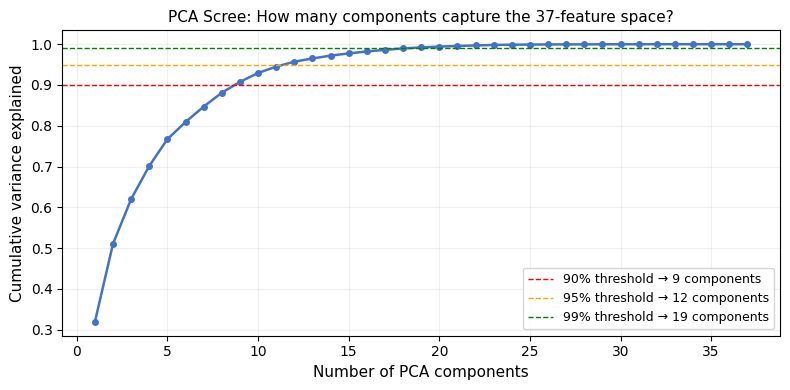


Components needed per variance threshold:
  80%  →   6 components
  85%  →   8 components
  90%  →   9 components
  95%  →  12 components
  99%  →  19 components

2. Mutual Information: Feature Relevance per Target


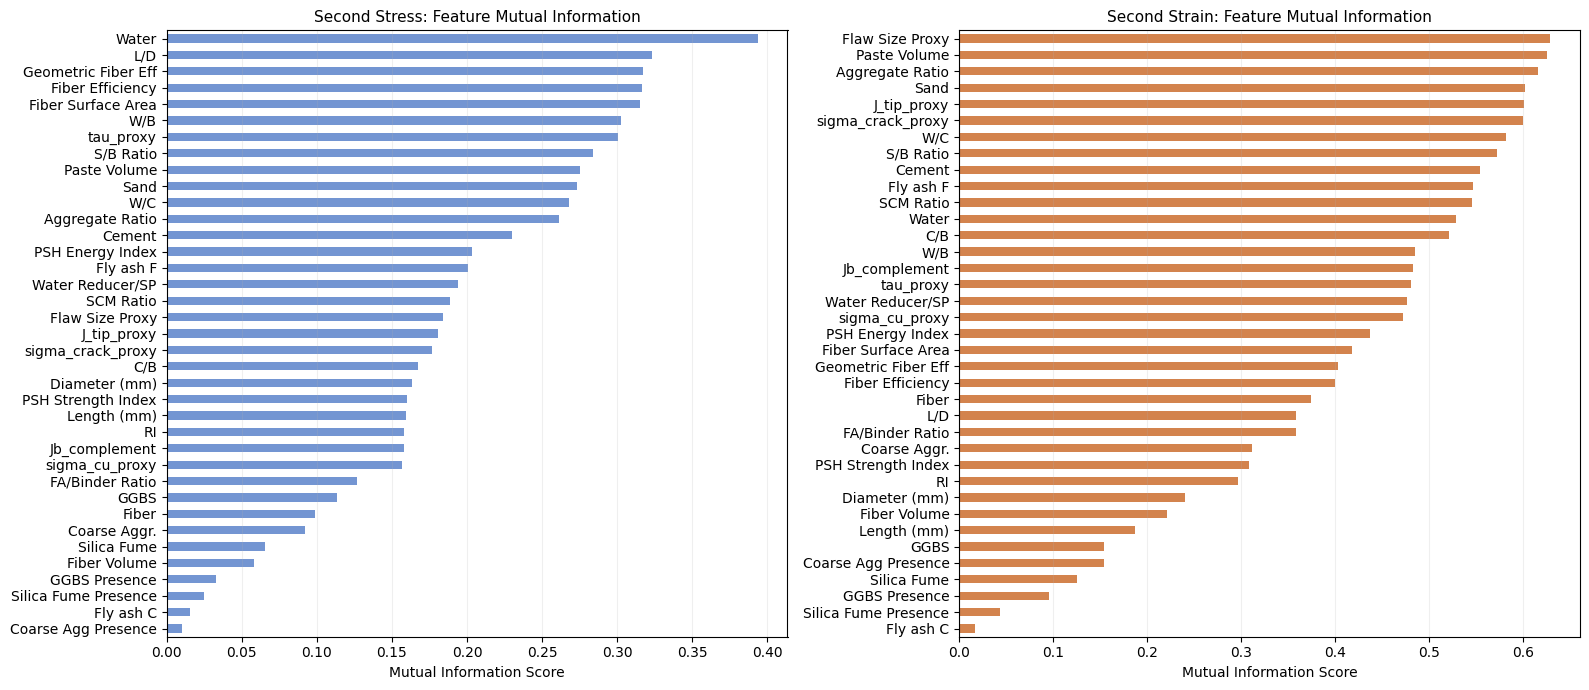


Strain — bottom 10 (low relevance candidates):
  RI                                  MI=0.2965
  Diameter (mm)                       MI=0.2409
  Fiber Volume                        MI=0.2209
  Length (mm)                         MI=0.1869
  GGBS                                MI=0.1547
  Coarse Agg Presence                 MI=0.1537
  Silica Fume                         MI=0.1253
  GGBS Presence                       MI=0.0953
  Silica Fume Presence                MI=0.0437
  Fly ash C                           MI=0.0165

Stress — bottom 10 (low relevance candidates):
  FA/Binder Ratio                     MI=0.1265
  GGBS                                MI=0.1137
  Fiber                               MI=0.0987
  Coarse Aggr.                        MI=0.0920
  Silica Fume                         MI=0.0658
  Fiber Volume                        MI=0.0582
  GGBS Presence                       MI=0.0332
  Silica Fume Presence                MI=0.0246
  Fly ash C                           MI

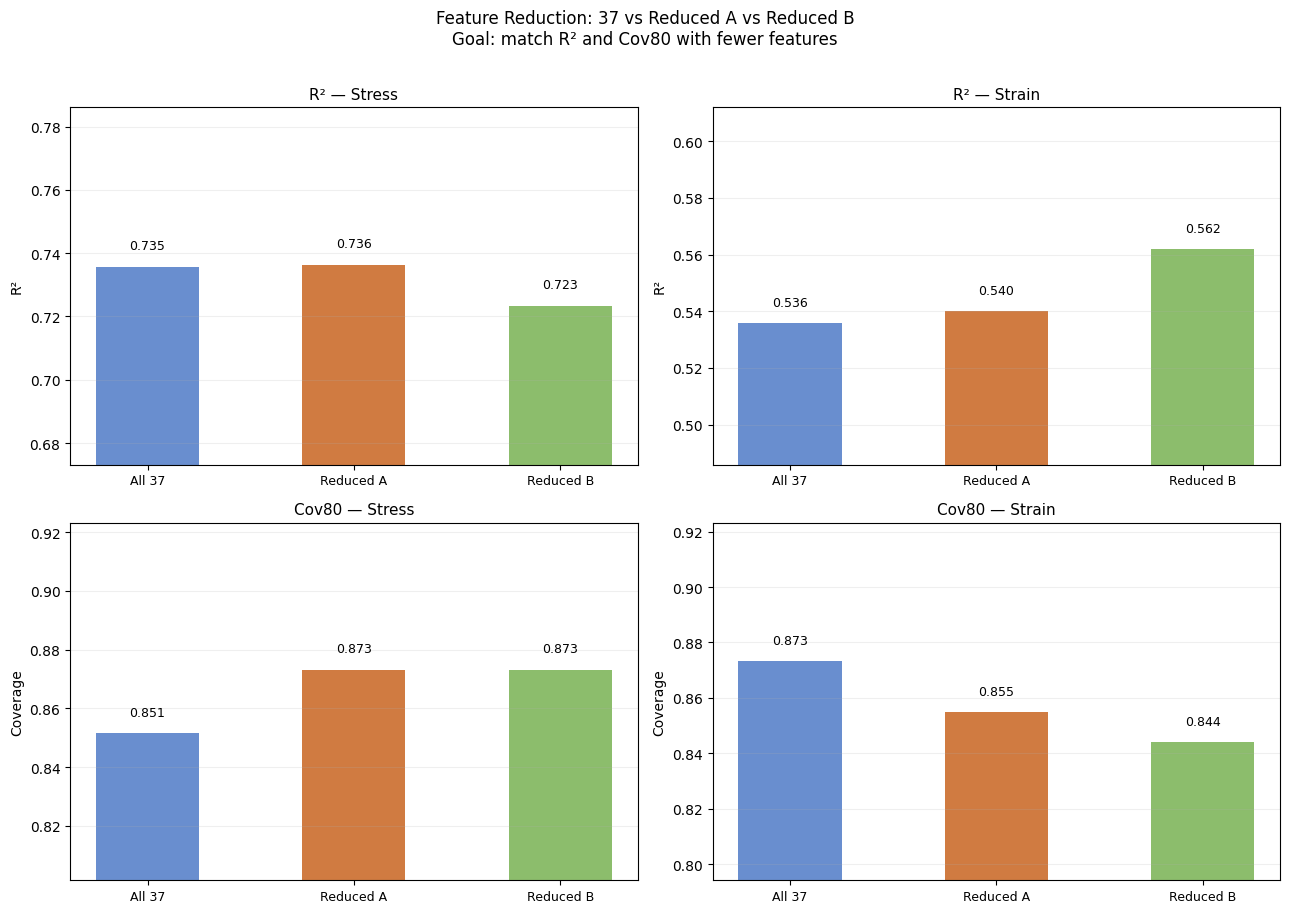


=== VERDICT ===

  Reduced A (32 features):
    R² Stress: 0.7361 (▲0.0007 vs baseline)
    R² Strain: 0.5402   (▲0.0043 vs baseline)
    Feature reduction: 37 → 32 (14% fewer)

  Reduced B (25 features):
    R² Stress: 0.7232 (▼0.0123 vs baseline)
    R² Strain: 0.5620   (▲0.0262 vs baseline)
    Feature reduction: 37 → 25 (32% fewer)


REDUCED_A = ['Fiber Volume', 'Length (mm)', 'Diameter (mm)', 'L/D', 'RI', 'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F', 'GGBS', 'Silica Fume', 'Water Reducer/SP', 'Fiber', 'C/B', 'W/C', 'W/B', 'FA/Binder Ratio', 'S/B Ratio', 'Paste Volume', 'SCM Ratio', 'Aggregate Ratio', 'Fiber Surface Area', 'GGBS Presence', 'Silica Fume Presence', 'Coarse Agg Presence', 'tau_proxy', 'Geometric Fiber Eff', 'PSH Strength Index', 'Jb_complement', 'J_tip_proxy', 'PSH Energy Index']

REDUCED_B = ['Length (mm)', 'Diameter (mm)', 'L/D', 'RI', 'Cement', 'Water', 'Sand', 'Fly ash F', 'Water Reducer/SP', 'Fiber', 'C/B', 'W/C', 'W/B', 'FA/Binder Ratio', 'S/B Ratio', 'P

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EPS = 1e-8

print("=" * 60)
print("1. PCA: Variance Explained by Number of Components")
print("=" * 60)

g_ref = build_group_means(df, "Second Strain")
X_ref = g_ref[ALL_37_FEATURES].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_ref)

pca_full = PCA().fit(X_sc)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#4472C4', ms=4, lw=1.8)
ax.axhline(0.90, color='red',    ls='--', lw=1, label='90% threshold → 9 components')
ax.axhline(0.95, color='orange', ls='--', lw=1, label='95% threshold → 12 components')
ax.axhline(0.99, color='green',  ls='--', lw=1, label='99% threshold → 19 components')
ax.set_xlabel('Number of PCA components', fontsize=11)
ax.set_ylabel('Cumulative variance explained', fontsize=11)
ax.set_title('PCA Scree: How many components capture the 37-feature space?', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

thresholds = {0.80: None, 0.85: None, 0.90: None, 0.95: None, 0.99: None}
for t in thresholds:
    thresholds[t] = int(np.searchsorted(cumvar, t)) + 1

print("\nComponents needed per variance threshold:")
for t, n in thresholds.items():
    print(f"  {t*100:.0f}%  →  {n:2d} components")


print("\n" + "=" * 60)
print("2. Mutual Information: Feature Relevance per Target")
print("=" * 60)

mi_results = {}
for target in ["Second Stress", "Second Strain"]:
    g = build_group_means(df, target)
    X = g[ALL_37_FEATURES].values
    y = g[target].values
    X_s = StandardScaler().fit_transform(X)
    mi = mutual_info_regression(X_s, y, random_state=42)
    mi_results[target] = pd.Series(mi, index=ALL_37_FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (target, mi_ser), color in zip(axes, mi_results.items(), ['#4472C4', '#C55A11']):
    mi_ser.plot(kind='barh', ax=ax, color=color, alpha=0.75)
    ax.invert_yaxis()
    ax.set_title(f'{target}: Feature Mutual Information', fontsize=11)
    ax.set_xlabel('Mutual Information Score', fontsize=10)
    ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout(); plt.show()

print("\nStrain — bottom 10 (low relevance candidates):")
for feat, val in mi_results["Second Strain"].tail(10).items():
    print(f"  {feat:<35} MI={val:.4f}")

print("\nStress — bottom 10 (low relevance candidates):")
for feat, val in mi_results["Second Stress"].tail(10).items():
    print(f"  {feat:<35} MI={val:.4f}")


print("\n" + "=" * 60)
print("3. Highly Correlated Feature Pairs (|r| > 0.95)")
print("=" * 60)

Xdf  = pd.DataFrame(X_sc, columns=ALL_37_FEATURES)
corr = Xdf.corr().abs()

redundant_pairs = []
for i in range(len(ALL_37_FEATURES)):
    for j in range(i+1, len(ALL_37_FEATURES)):
        if corr.iloc[i, j] > 0.95:
            redundant_pairs.append((ALL_37_FEATURES[i], ALL_37_FEATURES[j], corr.iloc[i, j]))
redundant_pairs.sort(key=lambda x: -x[2])

for a, b, r in redundant_pairs:
    print(f"  {a:<35} ↔  {b:<35}  r={r:.4f}")

# we're selecting wich one to drop from each pair: drop wtv has lower avg MI across both targets
mi_avg = (mi_results["Second Stress"] + mi_results["Second Strain"]) / 2
to_drop_corr = set()
for a, b, _ in redundant_pairs:
    drop = a if mi_avg[a] < mi_avg[b] else b
    to_drop_corr.add(drop)

print(f"\nSuggested drops from correlation (keep higher-MI member of each pair):")
for f in to_drop_corr:
    print(f"  DROP: {f}")


print("\n" + "=" * 60)
print("4. Recommended Reduced Feature Sets")
print("=" * 60)

# Strategy A: Drop correlation-redundant features only
REDUCED_A = [f for f in ALL_37_FEATURES if f not in to_drop_corr]

# Strategy B: Drop correlation-redundant + low MI for BOTH targets
# low MI threshold: bottom quartile in both targets
mi_strain_q25 = mi_results["Second Strain"].quantile(0.25)
mi_stress_q25 = mi_results["Second Stress"].quantile(0.25)
low_both = set(f for f in ALL_37_FEATURES
               if mi_results["Second Strain"][f] < mi_strain_q25
               and mi_results["Second Stress"][f] < mi_stress_q25)
REDUCED_B = [f for f in ALL_37_FEATURES if f not in (to_drop_corr | low_both)]

print(f"\nStrategy A — Drop correlated duplicates only:")
print(f"  37  →  {len(REDUCED_A)} features")
print(f"  Dropped: {sorted(to_drop_corr)}")

print(f"\nStrategy B — Drop correlated duplicates + low-MI for both targets:")
print(f"  37  →  {len(REDUCED_B)} features")
print(f"  Additionally dropped: {sorted(low_both - to_drop_corr)}")
print(f"  Kept features ({len(REDUCED_B)}):")
for f in REDUCED_B:
    print(f"    {f}")


# can change ts to false to skip and just use the feature lists above.
RUN_CV_COMPARISON = True

if RUN_CV_COMPARISON:
    print("\n" + "=" * 60)
    print("5. CV Comparison: 37 features vs Reduced A vs Reduced B")
    print("(Running CatBoost GroupKFold CVs — takes ~10-15 min)")
    print("=" * 60)

    comparison_results = []

    for label, feat_cols in [
        ("All 37",     ALL_37_FEATURES),
        ("Reduced A",  REDUCED_A),
        ("Reduced B",  REDUCED_B),
    ]:
        print(f"\n  Running: {label} ({len(feat_cols)} features)...")
        row = {"Config": label, "N Features": len(feat_cols)}
        for target in ["Second Stress", "Second Strain"]:
            g = build_group_means(df, target)

            # temporarily override ALL_37_FEATURES inside run_catboost_mondrian_c by monkey-patching the group df column selection
            import types

            y_all      = g[target].values
            groups_arr = g["group_id"].values
            gkf_local  = GroupKFold(n_splits=5)
            N = len(g)
            p50_arr = np.full(N, np.nan)
            lo_arr  = np.full(N, np.nan)
            hi_arr  = np.full(N, np.nan)

            for fold_idx, (tr_idx, val_idx) in enumerate(
                    gkf_local.split(g, y_all, groups_arr), start=1):
                g_tr = g.iloc[tr_idx].reset_index(drop=True)
                g_va = g.iloc[val_idx].reset_index(drop=True)
                y_tr = g_tr[target].values
                w_tr = g_tr["sample_weight"].values
                tr_uniq = g_tr["group_id"].unique()
                rng = np.random.default_rng(fold_idx); rng.shuffle(tr_uniq)
                fit_grp = set(tr_uniq[:int(0.75*len(tr_uniq))])
                fit_mask = g_tr["group_id"].isin(fit_grp).values
                cal_mask = ~fit_mask
                X_tr  = g_tr[feat_cols].values
                X_fit = g_tr.loc[fit_mask, feat_cols].values
                X_cal = g_tr.loc[cal_mask, feat_cols].values
                X_va  = g_va[feat_cols].values
                y_fit = y_tr[fit_mask]; y_cal = y_tr[cal_mask]; w_fit = w_tr[fit_mask]

                m50 = make_catboost_quantile(0.50, target); m50.fit(X_tr,y_tr,sample_weight=w_tr)
                m10 = make_catboost_quantile(0.10, target); m10.fit(X_tr,y_tr,sample_weight=w_tr)
                m90 = make_catboost_quantile(0.90, target); m90.fit(X_tr,y_tr,sample_weight=w_tr)
                f50 = make_catboost_quantile(0.50, target); f50.fit(X_fit,y_fit,sample_weight=w_fit)
                f10 = make_catboost_quantile(0.10, target); f10.fit(X_fit,y_fit,sample_weight=w_fit)
                f90 = make_catboost_quantile(0.90, target); f90.fit(X_fit,y_fit,sample_weight=w_fit)

                q10_va=m10.predict(X_va); q50_va=m50.predict(X_va); q90_va=m90.predict(X_va)
                q10_c=f10.predict(X_cal); q50_c=f50.predict(X_cal); q90_c=f90.predict(X_cal)
                q50_va_fit=f50.predict(X_va)

                scores=np.maximum(q10_c-y_cal, y_cal-q90_c)
                qhat=mondrian_qhat(scores, q50_c, q50_va_fit, alpha=0.20)
                p50_arr[val_idx]=np.maximum(q50_va,0)
                lo_arr[val_idx] =np.maximum(q10_va-qhat,0)
                hi_arr[val_idx] =np.maximum(q90_va+qhat,0)

            y_true = g[target].values
            short  = "Str" if "Strain" in target else "Stress"
            row[f"R2_{short}"]   = r2_score(y_true, p50_arr)
            row[f"MAE_{short}"]  = mean_absolute_error(y_true, p50_arr)
            row[f"Cov_{short}"]  = np.mean((y_true>=lo_arr)&(y_true<=hi_arr))
            row[f"Width_{short}"] = np.mean(hi_arr-lo_arr)
            print(f"    {target}: R2={row[f'R2_{short}']:.4f}  "
                  f"MAE={row[f'MAE_{short}']:.4f}  Cov80={row[f'Cov_{short}']:.3f}")
        comparison_results.append(row)

    results_df = pd.DataFrame(comparison_results).set_index("Config")
    print("\n\n=== FINAL COMPARISON TABLE ===")
    print(results_df.round(4).to_string())

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    cfgs   = results_df.index.tolist()
    x      = np.arange(len(cfgs))
    colors = ['#4472C4', '#C55A11', '#70AD47']
    width  = 0.5

    for ax, col, title, ylabel in [
        (axes[0,0], "R2_Stress",    "R² — Stress",          "R²"),
        (axes[0,1], "R2_Str",       "R² — Strain",          "R²"),
        (axes[1,0], "Cov_Stress",   "Cov80 — Stress",       "Coverage"),
        (axes[1,1], "Cov_Str",      "Cov80 — Strain",       "Coverage"),
    ]:
        vals = results_df[col].values
        bars = ax.bar(x, vals, width=width, color=colors[:len(cfgs)], alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(cfgs, fontsize=9)
        ax.set_title(title, fontsize=11); ax.set_ylabel(ylabel, fontsize=10)
        ax.set_ylim(max(0, vals.min() - 0.05), min(1.05, vals.max() + 0.05))
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)
        ax.grid(True, alpha=0.2, axis='y')

    plt.suptitle('Feature Reduction: 37 vs Reduced A vs Reduced B\n'
                 'Goal: match R² and Cov80 with fewer features',
                 fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()

    print("\n=== VERDICT ===")
    baseline_r2_stress = results_df.loc["All 37",    "R2_Stress"]
    baseline_r2_strain = results_df.loc["All 37",    "R2_Str"]
    for cfg in ["Reduced A", "Reduced B"]:
        d_stress = results_df.loc[cfg,"R2_Stress"] - baseline_r2_stress
        d_strain = results_df.loc[cfg,"R2_Str"]    - baseline_r2_strain
        n_feat   = results_df.loc[cfg,"N Features"]
        print(f"\n  {cfg} ({n_feat} features):")
        print(f"    R² Stress: {results_df.loc[cfg,'R2_Stress']:.4f} "
              f"({'▲' if d_stress>=0 else '▼'}{abs(d_stress):.4f} vs baseline)")
        print(f"    R² Strain: {results_df.loc[cfg,'R2_Str']:.4f}   "
              f"({'▲' if d_strain>=0 else '▼'}{abs(d_strain):.4f} vs baseline)")
        print(f"    Feature reduction: 37 → {n_feat} "
              f"({(37-n_feat)/37*100:.0f}% fewer)")

else:
    print("\nSkipped CV comparison (RUN_CV_COMPARISON=False).")
    print(f"Use REDUCED_A ({len(REDUCED_A)} features) or REDUCED_B ({len(REDUCED_B)} features)")
    print("by replacing ALL_37_FEATURES with the chosen list in run_catboost_mondrian_cv calls.")

print(f"\n\nREDUCED_A = {REDUCED_A}")
print(f"\nREDUCED_B = {REDUCED_B}")

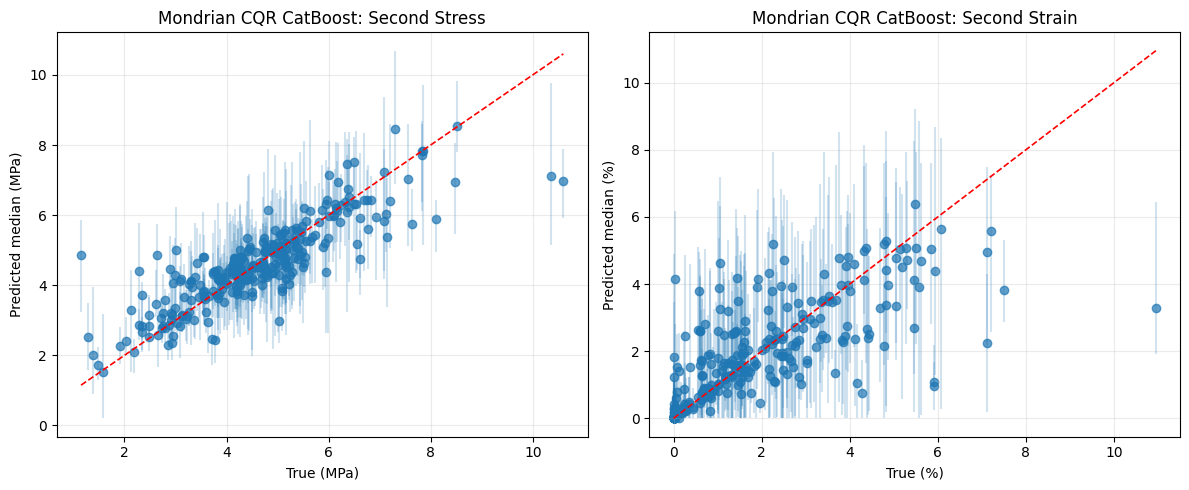

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, target, unit_mult, unit in [
    (axes[0], "Second Stress", 1.0, "MPa"),
    (axes[1], "Second Strain", 100.0, "%"),
]:
    g = ALL_RESULTS[target]["group_df"]
    y = g[target].values * unit_mult
    p = ALL_RESULTS[target]["p50"] * unit_mult
    lo = ALL_RESULTS[target]["lo"] * unit_mult
    hi = ALL_RESULTS[target]["hi"] * unit_mult

    ax.scatter(y, p, alpha=0.7)
    ax.vlines(y, lo, hi, alpha=0.2)
    lim0, lim1 = min(y.min(), p.min()), max(y.max(), p.max())
    ax.plot([lim0, lim1], [lim0, lim1], 'r--', lw=1.2)
    ax.set_title(f"Mondrian CQR CatBoost: {target}")
    ax.set_xlabel(f"True ({unit})")
    ax.set_ylabel(f"Predicted median ({unit})")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "scatter_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


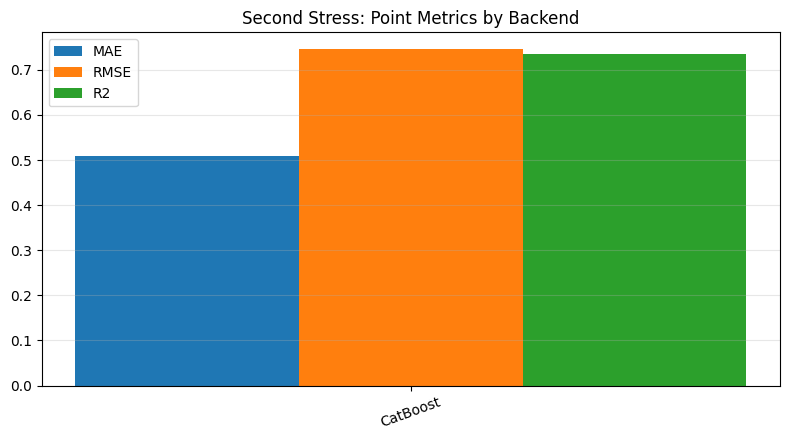

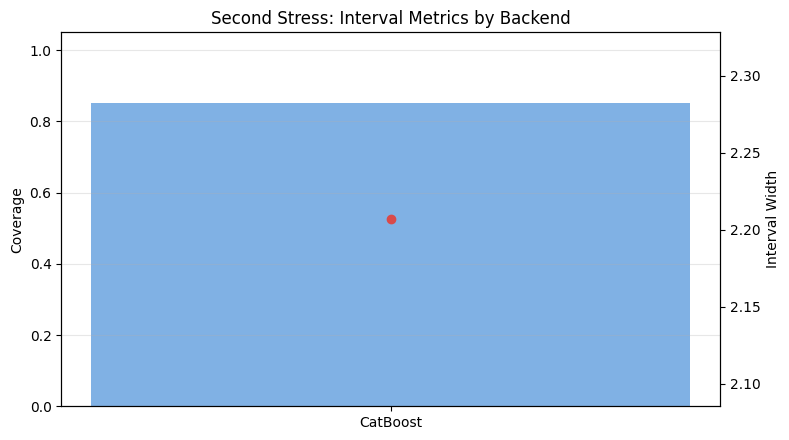

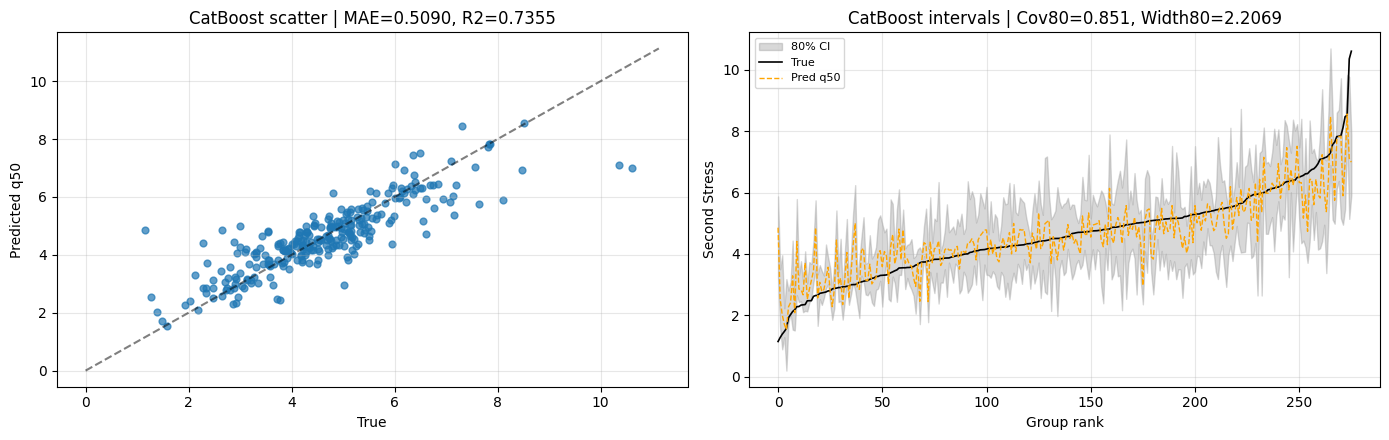

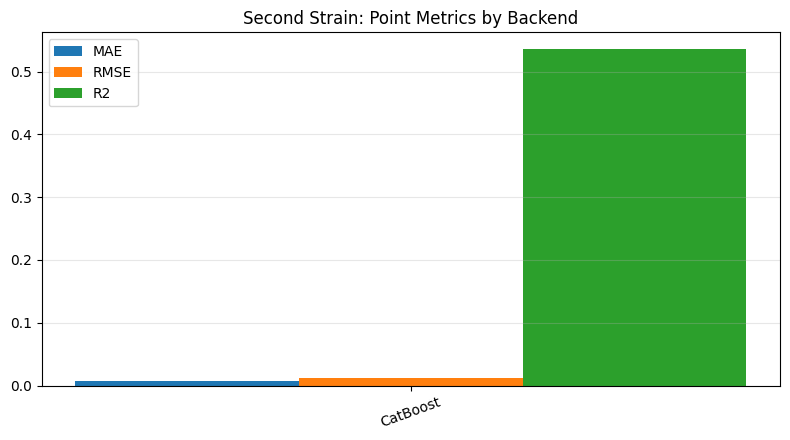

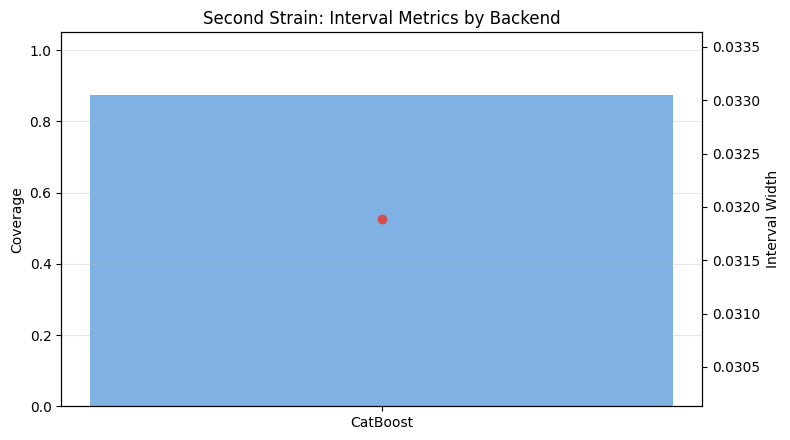

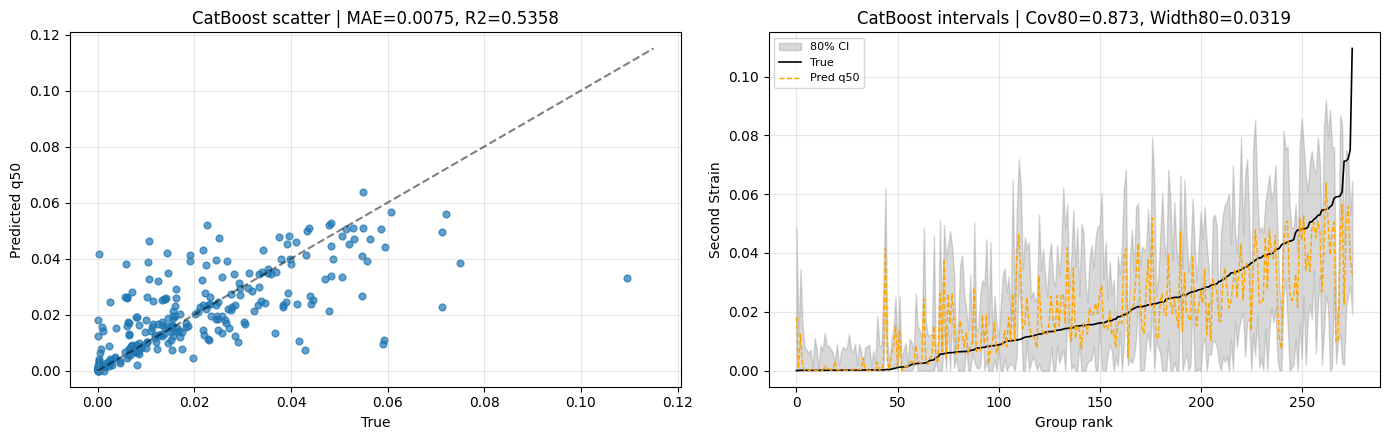

In [10]:
# Old backend-style plots (adapted for CatBoost-only Mondrian results)
def plot_catboost_backend_style(target):
    g = ALL_RESULTS[target]["group_df"]
    m = ALL_RESULTS[target]["metrics"]
    p50 = ALL_RESULTS[target]["p50"]
    lo = ALL_RESULTS[target]["lo"]
    hi = ALL_RESULTS[target]["hi"]

    results_df = pd.DataFrame([m], index=["CatBoost"])
    preds_store = {"CatBoost": (p50, lo, hi)}

    # 1) Metrics bar
    plt.figure(figsize=(8, 4.5))
    x = np.arange(len(results_df))
    plt.bar(x - 0.2, results_df["MAE"].values, width=0.2, label="MAE")
    plt.bar(x, results_df["RMSE"].values, width=0.2, label="RMSE")
    plt.bar(x + 0.2, results_df["R2"].values, width=0.2, label="R2")
    plt.xticks(x, results_df.index, rotation=20)
    plt.title(f"{target}: Point Metrics by Backend")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    safe = target.replace(" ", "_")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"catboost_{safe}_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 2) Coverage-width chart
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax2 = ax1.twinx()
    ax1.bar(results_df.index, results_df["Cov80"].values, color="#4a90d9", alpha=0.7, label="Cov80")
    ax2.plot(results_df.index, results_df["Width80"].values, color="#d94a4a", marker="o", label="Width80")
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel("Coverage")
    ax2.set_ylabel("Interval Width")
    ax1.set_title(f"{target}: Interval Metrics by Backend")
    ax1.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

    # 3) Scatter + interval panels
    y_true = g[target].values
    sort_idx = np.argsort(y_true)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    ax = axes[0]
    ax.scatter(y_true, p50, s=24, alpha=0.7)
    lim = max(np.max(y_true), np.max(p50)) * 1.05
    ax.plot([0, lim], [0, lim], "k--", alpha=0.5)
    ax.set_title(f"CatBoost scatter | MAE={m['MAE']:.4f}, R2={m['R2']:.4f}")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted q50")
    ax.grid(alpha=0.3)

    ax = axes[1]
    x = np.arange(len(y_true))
    ax.fill_between(x, lo[sort_idx], hi[sort_idx], color="gray", alpha=0.3, label="80% CI")
    ax.plot(x, y_true[sort_idx], "k-", lw=1.2, label="True")
    ax.plot(x, p50[sort_idx], color="orange", lw=1.0, ls="--", label="Pred q50")
    ax.set_title(f"CatBoost intervals | Cov80={m['Cov80']:.3f}, Width80={m['Width80']:.4f}")
    ax.set_xlabel("Group rank")
    ax.set_ylabel(target)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    safe = target.replace(" ", "_")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"catboost_{safe}_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_catboost_backend_style("Second Stress")
plot_catboost_backend_style("Second Strain")


In [11]:
PRICES = {
    'Cement': 0.30420, 'Water': 0.00220, 'Sand': 0.01980,
    'Fly ash C': 0.01349, 'Fly ash F': 0.01349, 'GGBS': 0.07860,
    'Coarse Aggr.': 0.01320, 'Silica Fume': 0.55000,
    'Water Reducer/SP': 1.10000,
}
MIX_COLS = ['Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F',
            'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer/SP']


def mix_cost(row_dict):
    return sum(row_dict.get(k, 0) * PRICES.get(k, 0) for k in MIX_COLS)


def build_features_from_mix(mix_arr):
    """Reconstruct the 37-feature vector from raw mix columns (numpy row)."""
    col = dict(zip(MIX_COLS + ['Fiber Volume', 'Length (mm)', 'Diameter (mm)',
                                 'L/D', 'RI', 'Fiber', 'W/C', 'W/B', 'C/B'],
                   mix_arr[:18]))
    d = {c: mix_arr[i] for i, c in enumerate(ALL_37_FEATURES[:18])}
    row_df = pd.DataFrame([mix_arr[:37]], columns=ALL_37_FEATURES)
    return row_df.values


def _compute_mondrian_qhat(g, target, alpha=0.20):
    """Fit calibration state on 25% hold-out of group means for deployment."""
    y_all      = g[target].values
    X_all      = g[ALL_37_FEATURES].values
    w_all      = g['sample_weight'].values
    groups_arr = g['group_id'].values

    rng = np.random.default_rng(42)
    uniq = np.unique(groups_arr)
    rng.shuffle(uniq)
    n_cal = max(1, int(0.25 * len(uniq)))
    cal_grp = set(uniq[:n_cal])

    fit_mask = np.array([gid not in cal_grp for gid in groups_arr])
    cal_mask = ~fit_mask

    X_fit, y_fit, w_fit = X_all[fit_mask], y_all[fit_mask], w_all[fit_mask]
    X_cal, y_cal        = X_all[cal_mask], y_all[cal_mask]

    if target == 'Second Stress':
        m10 = make_catboost_quantile(0.10, target); m10.fit(X_fit, y_fit, sample_weight=w_fit)
        m50 = make_catboost_quantile(0.50, target); m50.fit(X_fit, y_fit, sample_weight=w_fit)
        m90 = make_catboost_quantile(0.90, target); m90.fit(X_fit, y_fit, sample_weight=w_fit)
    else:
        m10 = make_catboost_quantile(0.10, target); m10.fit(X_fit, y_fit, sample_weight=w_fit)
        m50 = make_catboost_quantile(0.50, target); m50.fit(X_fit, y_fit, sample_weight=w_fit)
        m90 = make_catboost_quantile(0.90, target); m90.fit(X_fit, y_fit, sample_weight=w_fit)

    q10_c, q50_c, q90_c = m10.predict(X_cal), m50.predict(X_cal), m90.predict(X_cal)
    q50_full             = m50.predict(X_all)

    scores = np.maximum(q10_c - y_cal, y_cal - q90_c)
    qhat   = mondrian_qhat(scores, q50_c, q50_full, alpha)

    return {'m10': m10, 'm50': m50, 'm90': m90, 'qhat': qhat, 'q50_full': q50_full}


print('Building inverse-pipeline calibration states ...')
CAL_STRESS = _compute_mondrian_qhat(
    ALL_RESULTS['Second Stress']['group_df'], 'Second Stress')
CAL_STRAIN = _compute_mondrian_qhat(
    ALL_RESULTS['Second Strain']['group_df'], 'Second Strain')
print('Done.')


def _predict_with_interval(X_new, cal, target):
    """Point + 80% Mondrian CQR interval for a new sample."""
    q10 = cal['m10'].predict(X_new)
    q50 = cal['m50'].predict(X_new)
    q90 = cal['m90'].predict(X_new)
    qhat = mondrian_qhat(
        np.array([0.0]),          # dummy scores — reuse stored qhat
        cal['q50_full'][:1],      # reference bin quantiles
        q50, alpha=0.20,
    )
    lo = np.maximum(q10 - cal['qhat'], 0)
    hi = np.maximum(q90 + cal['qhat'], 0)
    return q50, lo, hi


def inverse_design_tiers(stress_range, strain_range_pct,
                          fiber_params, n_samples=100_000, top_k=50,
                          n_refine=300, verbose=True):
    """
    Random-search inverse design with 3 cost tiers.

    Params

    stress_range      : (s_min, s_max) in MPa
    strain_range_pct  : (e_min, e_max) in percent
    fiber_params      : (Vf, L_mm, D_mm, LD, RI, kg_per_m3)
    """
    s_min, s_max = stress_range
    e_min, e_max = strain_range_pct[0] / 100.0, strain_range_pct[1] / 100.0
    Vf, L_mm, D_mm, LD, RI, fiber_kg = fiber_params

    rng = np.random.RandomState(42)

    def _sample_mixes(n):
        cement  = rng.uniform(300, 700, n)
        water   = rng.uniform(150, 350, n)
        sand    = rng.uniform(0,   500, n)
        fa_c    = rng.uniform(0,   300, n)
        fa_f    = rng.uniform(0,   300, n)
        ggbs    = rng.uniform(0,   200, n)
        coarse  = rng.uniform(0,   100, n)
        sf      = rng.uniform(0,    50, n)
        sp      = rng.uniform(0,    10, n)
        return np.column_stack([cement, water, sand, fa_c, fa_f,
                                 ggbs, coarse, sf, sp])

    raw_mixes = _sample_mixes(n_samples)

    rows = []
    for row in raw_mixes:
        cement, water, sand, fa_c, fa_f, ggbs, coarse, sf, sp = row
        binder  = cement + fa_f + fa_c + ggbs + sf
        paste   = binder + water
        total_a = sand + coarse
        w_b     = water / (binder + EPS)
        w_c     = water / (cement + EPS)
        c_b     = cement / (binder + EPS)
        scm     = (fa_f + fa_c + ggbs + sf) / (binder + EPS)
        agg_r   = total_a / (paste + EPS)
        fa_b    = (fa_f + fa_c) / (binder + EPS)
        s_b     = sand / (binder + EPS)
        fsa     = np.pi * D_mm * L_mm * Vf
        fe      = Vf * LD
        ggbs_p  = float(ggbs > 0)
        sf_p    = float(sf > 0)
        ca_p    = float(coarse > 0)
        tau     = Vf * LD / (D_mm + EPS)
        flaw    = agg_r / (w_b + EPS)
        geo_fe  = Vf * LD * RI
        sig_cu  = cement / (w_b + EPS)
        sig_cr  = 1.0 / (flaw + EPS)
        psh_s   = sig_cu * Vf * LD
        jb_c    = 1.0 / (sig_cu * LD**2 + EPS)
        j_tip   = 1.0 / (flaw + EPS)
        psh_e   = Vf * LD**2 * RI
        rows.append([
            Vf, L_mm, D_mm, LD, RI,
            cement, water, sand, fa_c, fa_f, ggbs, coarse, sf, sp,
            Vf, c_b, w_c, w_b,
            fa_b, s_b,
            paste, scm, agg_r, fsa, fe, ggbs_p, sf_p, ca_p,
            tau, flaw, geo_fe, sig_cu, sig_cr, psh_s, jb_c, j_tip, psh_e,
        ])
    X_cand = np.array(rows, dtype=float)

    # Forward predict
    p_stress = m_stress_q50.predict(X_cand)
    p_strain = m_strain_q50.predict(X_cand)

    mask = (p_stress >= s_min) & (p_stress <= s_max) & \
           (p_strain >= e_min) & (p_strain <= e_max)
    if mask.sum() == 0:
        print('No candidates in target window — try wider ranges.')
        return None

    X_pass   = X_cand[mask]
    mix_pass = raw_mixes[mask]
    costs    = np.array([mix_cost(dict(zip(MIX_COLS, m))) + fiber_kg * PRICES.get('Water Reducer/SP', 1.1)
                         for m in mix_pass])

    if verbose:
        print(f'Phase 1: {mask.sum():,} / {n_samples:,} candidates passed filter.')

    sort_idx   = np.argsort(costs)
    tier_size  = max(1, len(sort_idx) // 3)
    budget_idx   = sort_idx[:tier_size]
    standard_idx = sort_idx[tier_size:2*tier_size]
    premium_idx  = sort_idx[2*tier_size:]

    def _tier_stats(idx, label):
        if len(idx) == 0:
            return None
        sub_stress = p_stress[mask][idx]
        best = idx[np.argsort(np.abs(sub_stress - (s_min + s_max) / 2))[:top_k]]
        X_b = X_pass[best]
        c_b = costs[best]
        ps  = m_stress_q50.predict(X_b)
        pe  = m_strain_q50.predict(X_b)
        best_i = np.argmin(c_b)
        return {
            'mix':            dict(zip(MIX_COLS, mix_pass[best[best_i]])),
            'pred_stress_MPa': float(ps[best_i]),
            'pred_strain_pct': float(pe[best_i]) * 100,
            'cost_mean':       float(c_b.mean()),
            'cost_90ci_low':   float(np.percentile(c_b, 5)),
            'cost_90ci_high':  float(np.percentile(c_b, 95)),
            'n_candidates':    len(best),
        }

    tiers = {
        'Budget':   _tier_stats(budget_idx,   'Budget'),
        'Standard': _tier_stats(standard_idx, 'Standard'),
        'Premium':  _tier_stats(premium_idx,  'Premium'),
    }
    return tiers


def print_tiers(tiers, stress_range, strain_range_pct):
    if tiers is None:
        print('No results.')
        return
    print(f'Target: Stress {stress_range[0]}–{stress_range[1]} MPa, '
          f'Strain {strain_range_pct[0]}–{strain_range_pct[1]} %')
    print('=' * 64)
    for label, t in tiers.items():
        if t is None:
            continue
        print(f'  {label}')
        print(f'    Predicted stress : {t["pred_stress_MPa"]:.2f} MPa')
        print(f'    Predicted strain : {t["pred_strain_pct"]:.2f} %')
        print(f'    Cost range (90%) : {t["cost_90ci_low"]:.3f} – {t["cost_90ci_high"]:.3f} USD/m³')
        print(f'    Best mix (kg/m³) :')
        for k, v in t['mix'].items():
            print(f'      {k:<22} {v:.1f}')
        print()


Building inverse-pipeline calibration states ...
Done.


Phase 1: 24,766 / 100,000 candidates passed filter.
Target: Stress 3.0–6.0 MPa, Strain 2.0–5.0 %
  Budget
    Predicted stress : 4.48 MPa
    Predicted strain : 2.19 %
    Cost range (90%) : 159.770 – 191.238 USD/m³
    Best mix (kg/m³) :
      Cement                 302.6
      Water                  157.8
      Sand                   47.5
      Fly ash C              273.7
      Fly ash F              249.4
      GGBS                   102.1
      Coarse Aggr.           40.1
      Silica Fume            3.5
      Water Reducer/SP       4.3

  Standard
    Predicted stress : 4.49 MPa
    Predicted strain : 2.10 %
    Cost range (90%) : 194.065 – 229.701 USD/m³
    Best mix (kg/m³) :
      Cement                 403.1
      Water                  165.5
      Sand                   48.9
      Fly ash C              277.2
      Fly ash F              229.5
      GGBS                   188.3
      Coarse Aggr.           54.6
      Silica Fume            28.7
      Water Reducer/SP       1

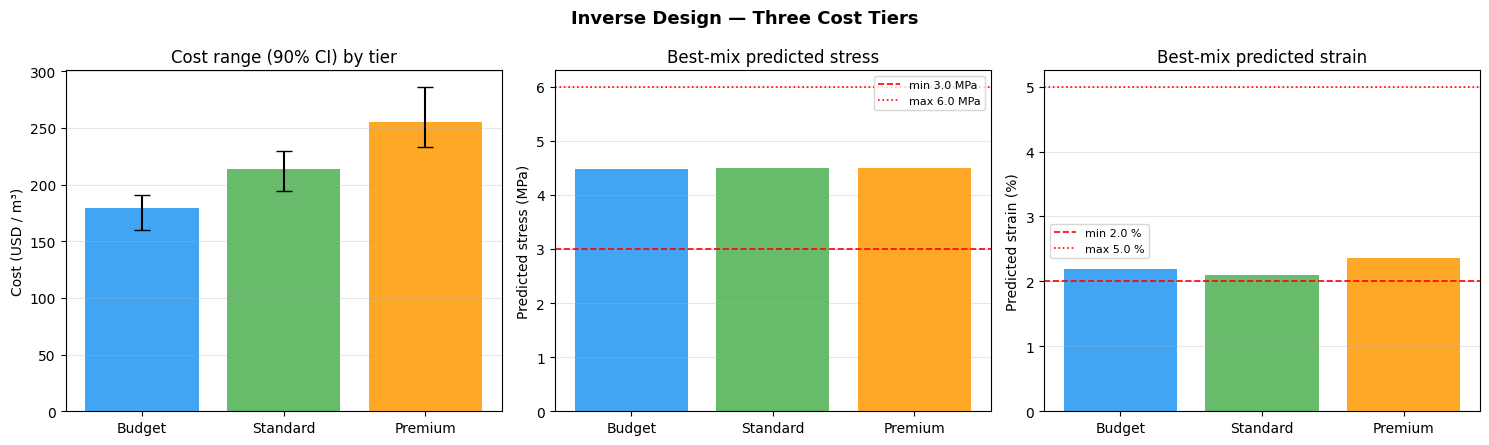

In [12]:
TARGET_STRESS = (3.0, 6.0)   # MPa
TARGET_STRAIN = (2.0, 5.0)   # percent
PVA_FIBER = (0.02, 12.0, 0.039, 307.69, 6.15, 26.0)  # Vf, L, D, L/D, RI, kg/m³

tiers_cb = inverse_design_tiers(TARGET_STRESS, TARGET_STRAIN, PVA_FIBER)
print_tiers(tiers_cb, TARGET_STRESS, TARGET_STRAIN)

if tiers_cb:
    labels       = ['Budget', 'Standard', 'Premium']
    means        = [tiers_cb[l]['cost_mean']       for l in labels]
    los          = [tiers_cb[l]['cost_90ci_low']   for l in labels]
    his          = [tiers_cb[l]['cost_90ci_high']  for l in labels]
    stress_vals  = [tiers_cb[l]['pred_stress_MPa'] for l in labels]
    strain_vals  = [tiers_cb[l]['pred_strain_pct'] for l in labels]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # Cost ranges
    ax = axes[0]
    err_lo = [m - l for m, l in zip(means, los)]
    err_hi = [h - m for m, h in zip(means, his)]
    ax.bar(labels, means, yerr=[err_lo, err_hi], capsize=6,
           color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
    ax.set_ylabel('Cost (USD / m³)')
    ax.set_title('Cost range (90% CI) by tier')
    ax.grid(axis='y', alpha=0.3)

    # Predicted stress
    ax = axes[1]
    ax.bar(labels, stress_vals, color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
    ax.axhline(TARGET_STRESS[0], color='red', ls='--', lw=1.2, label=f'min {TARGET_STRESS[0]} MPa')
    ax.axhline(TARGET_STRESS[1], color='red', ls=':',  lw=1.2, label=f'max {TARGET_STRESS[1]} MPa')
    ax.set_ylabel('Predicted stress (MPa)')
    ax.set_title('Best-mix predicted stress')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # Predicted strain
    ax = axes[2]
    ax.bar(labels, strain_vals, color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
    ax.axhline(TARGET_STRAIN[0], color='red', ls='--', lw=1.2, label=f'min {TARGET_STRAIN[0]} %')
    ax.axhline(TARGET_STRAIN[1], color='red', ls=':',  lw=1.2, label=f'max {TARGET_STRAIN[1]} %')
    ax.set_ylabel('Predicted strain (%)')
    ax.set_title('Best-mix predicted strain')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Inverse Design — Three Cost Tiers', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'inverse_design_tiers.png', dpi=150, bbox_inches='tight')
    plt.show()
